In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("/content/Titanic-Dataset.csv")
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


BASIC INFO

In [ ]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
df.shape

(891, 12)

In [ ]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          850 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,850.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,28.953392,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.450399,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,21.750000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,26.507589,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,36.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


CHECK MISSING VALUES

In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,41
SibSp,0
Parch,0
Ticket,0
Fare,0


<Axes: >

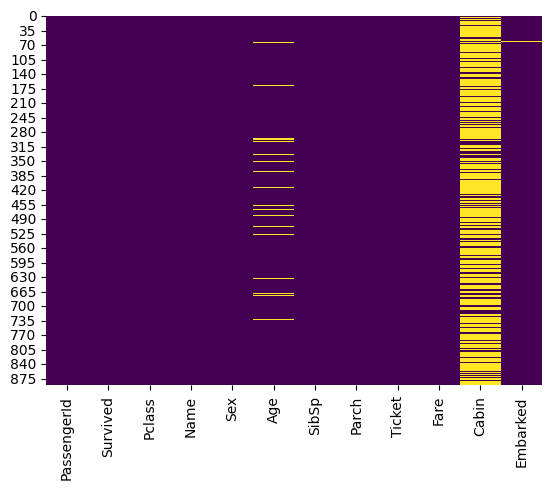

In [ ]:
sns.heatmap(df.isnull(),cbar=False,cmap="viridis")

HANDLE MISSING VALUES

In [ ]:
df['Age'].fillna(df['Age'].median(),inplace=True)

In [ ]:
df['Embarked'].fillna(df['Embarked'].mode()[0],inplace=True)

In [ ]:
df.drop(columns=['Cabin'],inplace=True)

UNIVARIATE ANALYSIS

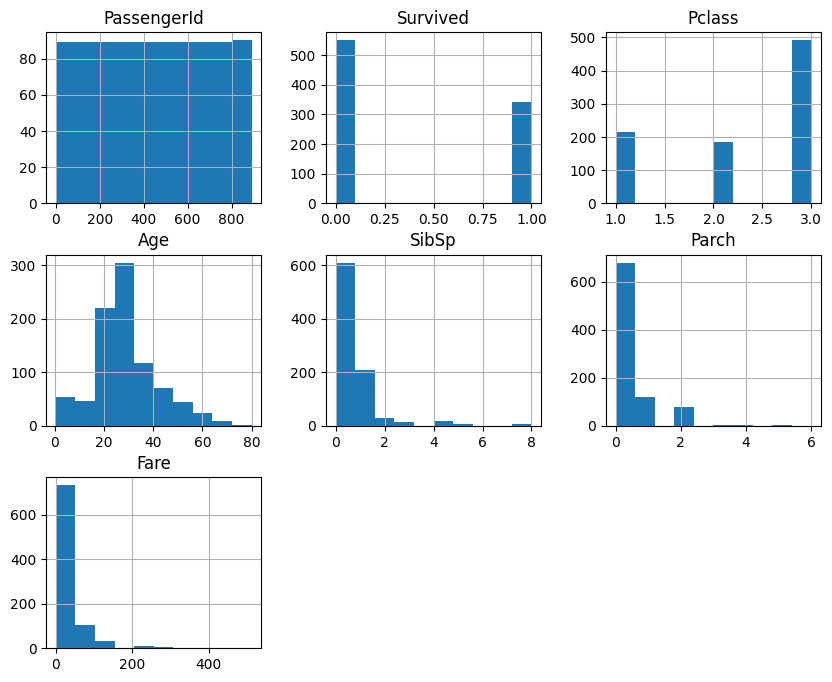

In [ ]:
#numerical
df.hist(figsize=(10,8))
plt.show()

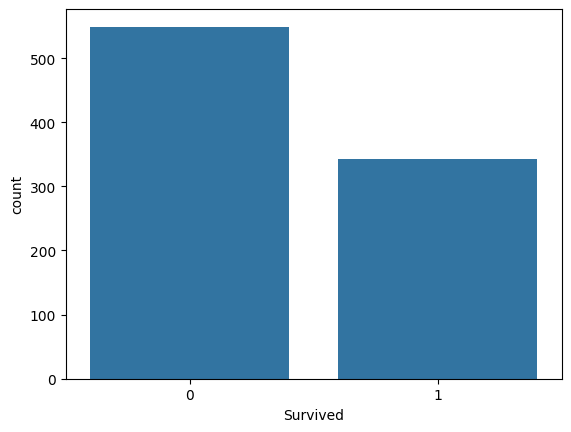

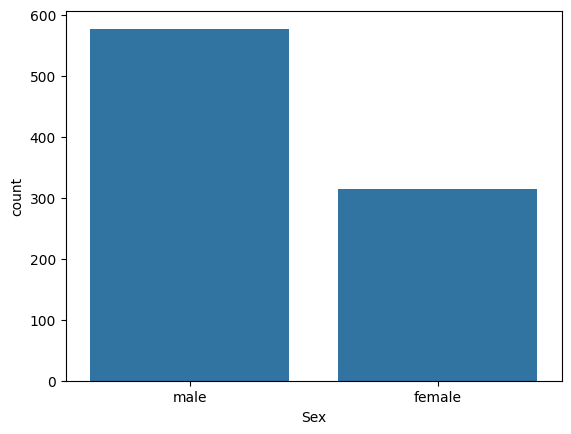

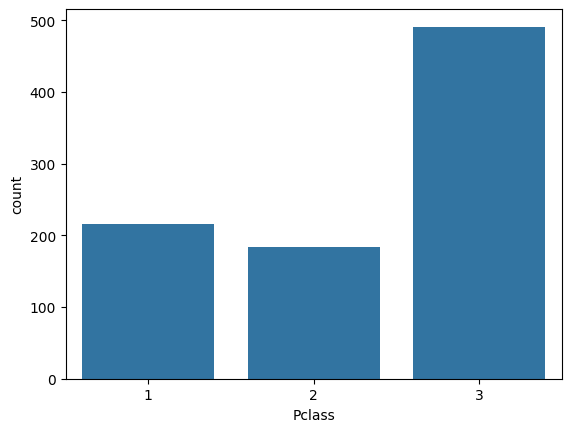

In [ ]:
#categorical
sns.countplot(x='Survived',data=df)
plt.show()

sns.countplot(x='Sex',data=df)
plt.show()

sns.countplot(x='Pclass',data=df)
plt.show()

BIVARIATE ANALYSIS

<Axes: xlabel='Survived', ylabel='count'>

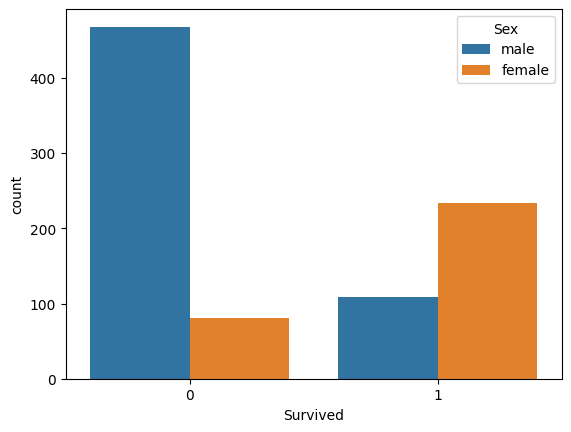

In [ ]:
#Survival vs Gender
sns.countplot(x='Survived',hue='Sex',data=df)



<Axes: xlabel='Survived', ylabel='count'>

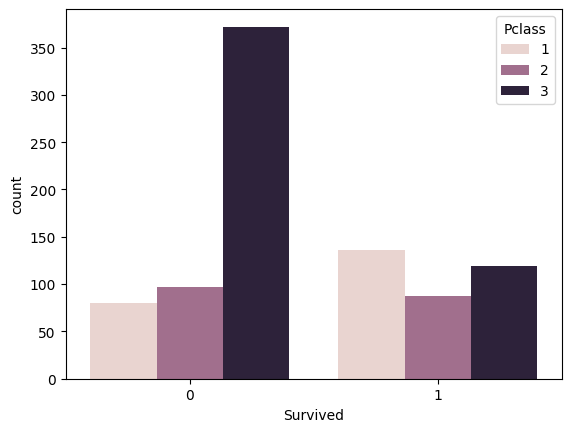

In [ ]:
#survival vs class
sns.countplot(x='Survived',hue='Pclass',data=df)



<Axes: xlabel='Age', ylabel='Count'>

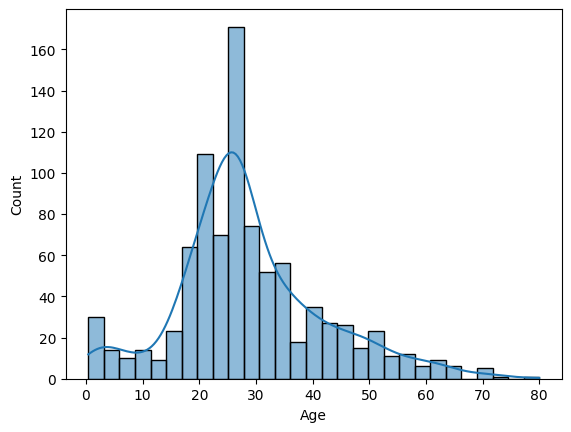

In [ ]:
#Age distribution
sns.histplot(df['Age'],kde=True)



<Axes: xlabel='Fare', ylabel='Count'>

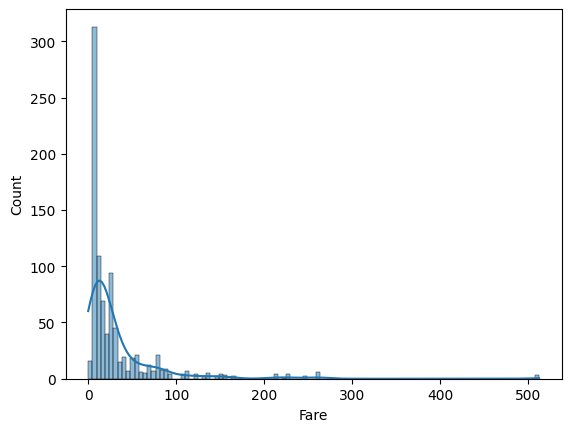

In [ ]:
#Fare distribution
sns.histplot(df['Fare'],kde=True)

CORRELATION ANALYSIS

<Axes: >

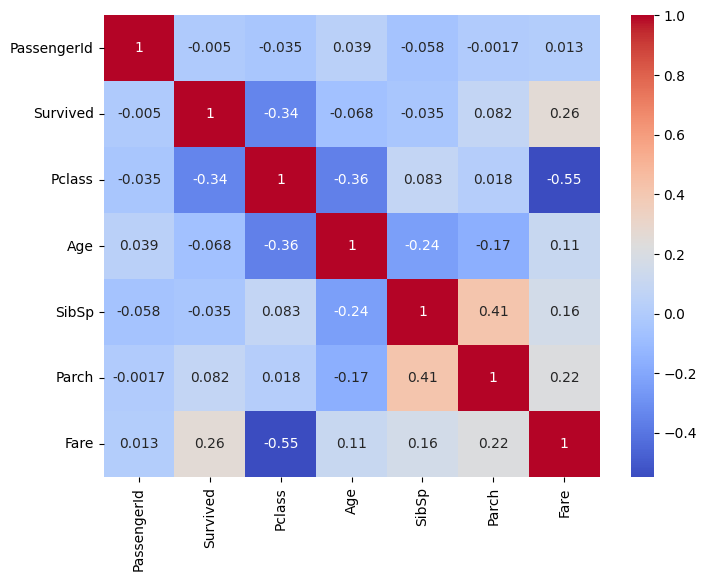

In [ ]:
numeric_df=df.select_dtypes(include=['int64','float64'])
corr=numeric_df.corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr,annot=True,cmap='coolwarm')

OUTLIER DETECTION

<Axes: xlabel='Age'>

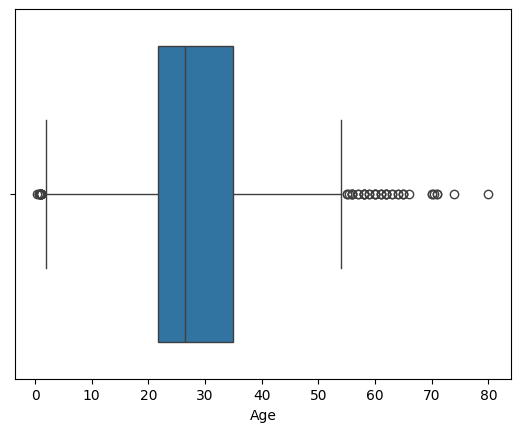

In [ ]:
sns.boxplot(x=df['Age'])


<Axes: xlabel='Fare'>

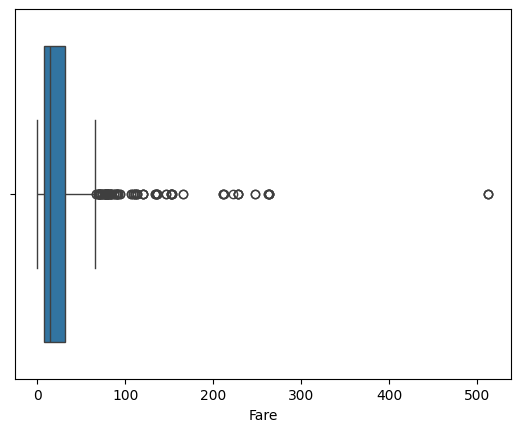

In [ ]:
sns.boxplot(x=df['Fare'])

FEATURE ENGINEERING

In [ ]:
# Family Size
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# Age Groups
df['AgeGroup'] = pd.cut(df['Age'], bins=[0,12,18,35,60,100],
                        labels=['Child','Teen','Adult','MidAge','Senior'])

DROP UNNECESSARY COLUMNS

In [ ]:
df.drop(['Name', 'Ticket', 'PassengerId'], axis=1, inplace=True)

ENCODING CATEGORICAL VARIABLES

In [ ]:
df = pd.get_dummies(df, drop_first=True)